# VinoLens - Phase 1: Exploratory Data Analysis (EDA)

Welcome to the first step of our machine learning pipeline!

### Goals of this notebook:
1. **Load and inspect** the Wine Quality dataset.
2. **Check data health** (dimensions, types, missing values, duplicates).
3. **Analyze statistical properties** (mean, spread, outliers).
4. **Understand the target variable** (quality score).
5. **Examine feature correlations** to guide feature engineering and model selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual styling
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# Path to the raw dataset (from ml/notebooks/, go up two levels to data/raw/)
DATA_PATH = '../../data/raw/WineQT.csv'

# Load dataset into pandas DataFrame
df = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully!')
df.head()

Dataset loaded successfully!


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [2]:
# 1. Dataset Dimensions
print(f"Dataset Shape: {df.shape[0]} rows (wines), {df.shape[1]} columns (features)")
print("-" * 50)

# 2. Check Data Types & Missing Values
print("Missing values per column:")
print(df.isnull().sum())
print("-" * 50)

# 3. Check for Duplicate Rows
print(f"Duplicate rows count: {df.duplicated().sum()}")
print("-" * 50)

# 4. Statistical Summary
# We transpose (.T) so features are rows and metrics (mean, std, min, max) are columns
df.describe().T

Dataset Shape: 1143 rows (wines), 13 columns (features)
--------------------------------------------------
Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
--------------------------------------------------
Duplicate rows count: 0
--------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


Dropped 'Id' column successfully. Remaining columns: 12

Wine count per quality score:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


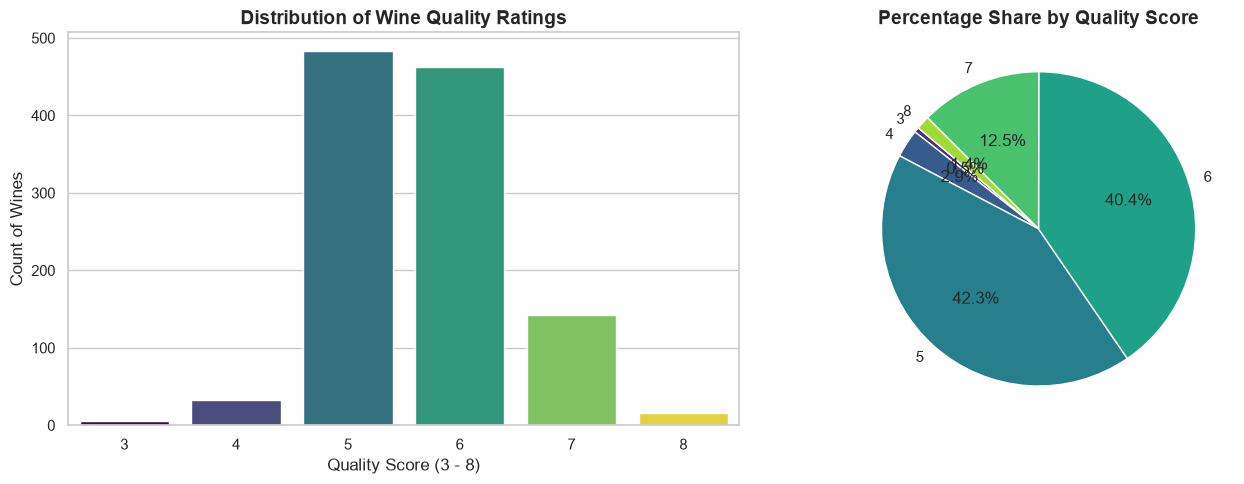

In [3]:
# 1. Drop the arbitrary 'Id' column so it does not interfere with analysis
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
    print("Dropped 'Id' column successfully. Remaining columns:", len(df.columns))

# 2. Inspect the distribution of Quality ratings
quality_counts = df['quality'].value_counts().sort_index()
print("\nWine count per quality score:")
print(quality_counts)

# 3. Visualize the Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot (Bar chart of frequency)
sns.countplot(x='quality', data=df, palette='viridis', hue='quality', legend=False, ax=axes[0])
axes[0].set_title("Distribution of Wine Quality Ratings", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Quality Score (3 - 8)")
axes[0].set_ylabel("Count of Wines")

# Percentage breakdown
quality_pct = (df['quality'].value_counts(normalize=True).sort_index() * 100)
axes[1].pie(quality_pct, labels=quality_pct.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(quality_pct)), startangle=140)
axes[1].set_title("Percentage Share by Quality Score", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

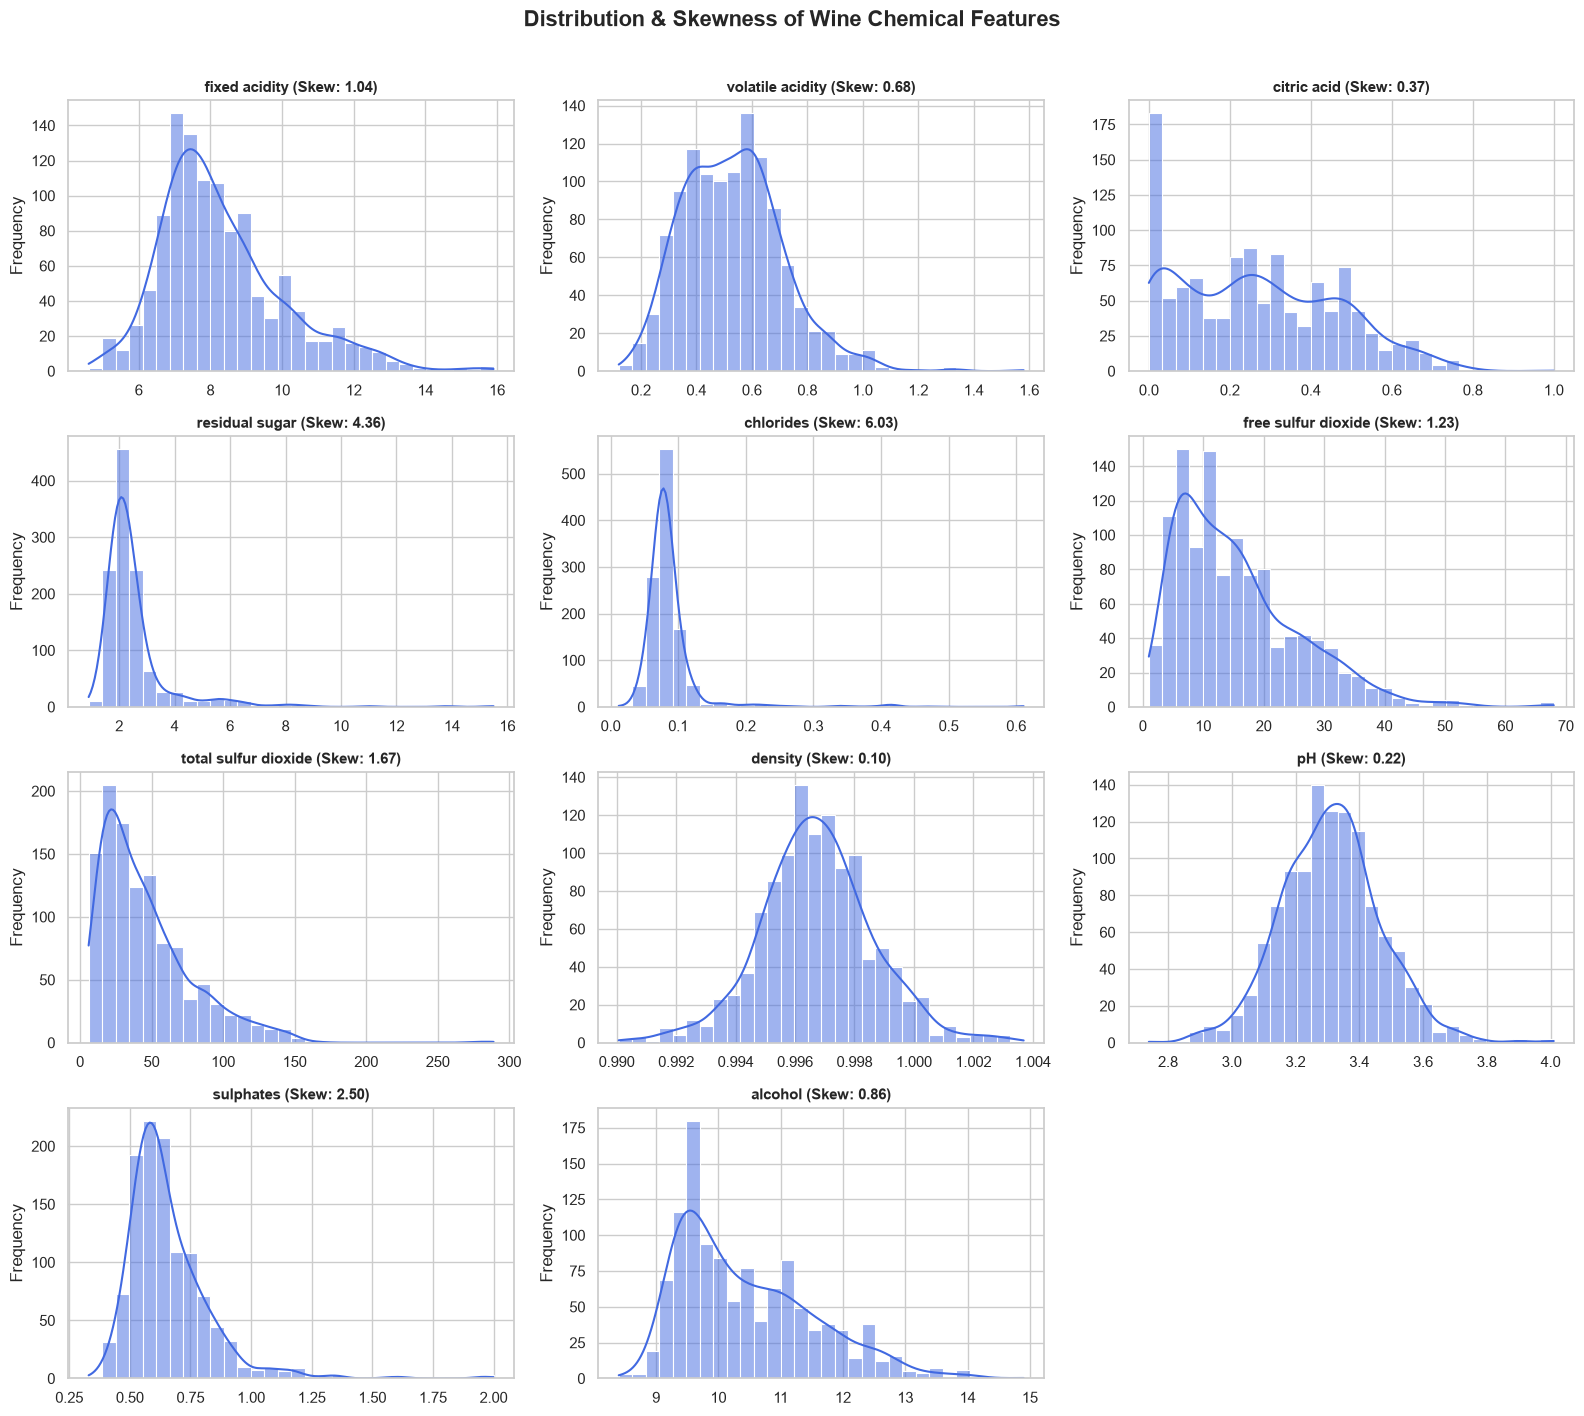

In [4]:
# List all 11 chemical input features (excluding 'quality')
features = [col for col in df.columns if col != 'quality']

# Create a 4x3 grid of subplots for the 11 features
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 14))
axes = axes.flatten()

# Plot histogram + KDE for each feature
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue', bins=30)
    axes[i].set_title(f"{col} (Skew: {df[col].skew():.2f})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

# Hide the unused 12th subplot in the grid
fig.delaxes(axes[-1])

plt.suptitle("Distribution & Skewness of Wine Chemical Features", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Correlation of each chemical feature with Quality:
alcohol                 0.485
sulphates               0.258
citric acid             0.241
fixed acidity           0.122
residual sugar          0.022
pH                     -0.052
free sulfur dioxide    -0.063
chlorides              -0.124
density                -0.175
total sulfur dioxide   -0.183
volatile acidity       -0.407
Name: quality, dtype: float64
--------------------------------------------------


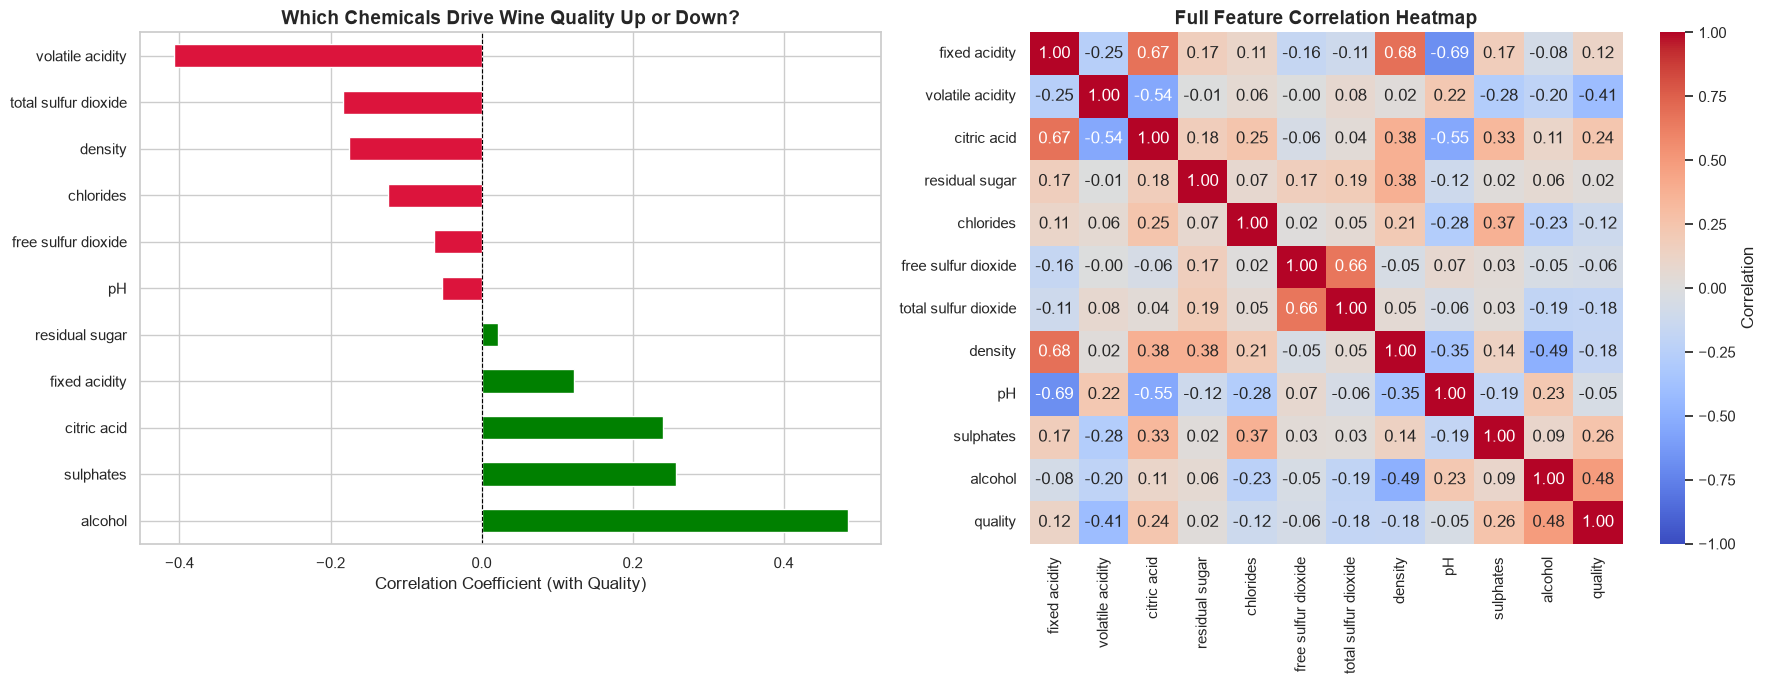

In [5]:
# 1. Compute Pearson correlation between all features
corr_matrix = df.corr()

# 2. Extract how each feature correlates specifically with 'quality'
quality_corr = corr_matrix['quality'].drop('quality').sort_values(ascending=False)

print("Correlation of each chemical feature with Quality:")
print(quality_corr.round(3))
print("-" * 50)

# 3. Visualize: (Left) Bar chart of correlation with Quality, (Right) Full Heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: Direct correlation with quality
colors = ['green' if x > 0 else 'crimson' for x in quality_corr.values]
quality_corr.plot(kind='barh', ax=axes[0], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title("Which Chemicals Drive Wine Quality Up or Down?", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Correlation Coefficient (with Quality)")

# Plot B: Full heatmap across all features
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title("Full Feature Correlation Heatmap", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()